In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset & EDA

In [7]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [8]:
df = pd.read_csv(r'C:\Users\faraz\Downloads\House Price Prediction Dataset.csv')

In [9]:
print (df.shape)

(2000, 10)


In [10]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [11]:
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [12]:
print(df.dtypes)

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


In [13]:
df.describe(include='all')

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000,2000,2000,2000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Downtown,Fair,No,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,558,521,1038,NaN
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,NaN,NaN,NaN,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,NaN,NaN,NaN,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,NaN,NaN,NaN,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,NaN,NaN,NaN,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,NaN,NaN,NaN,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,NaN,NaN,NaN,780086.000000


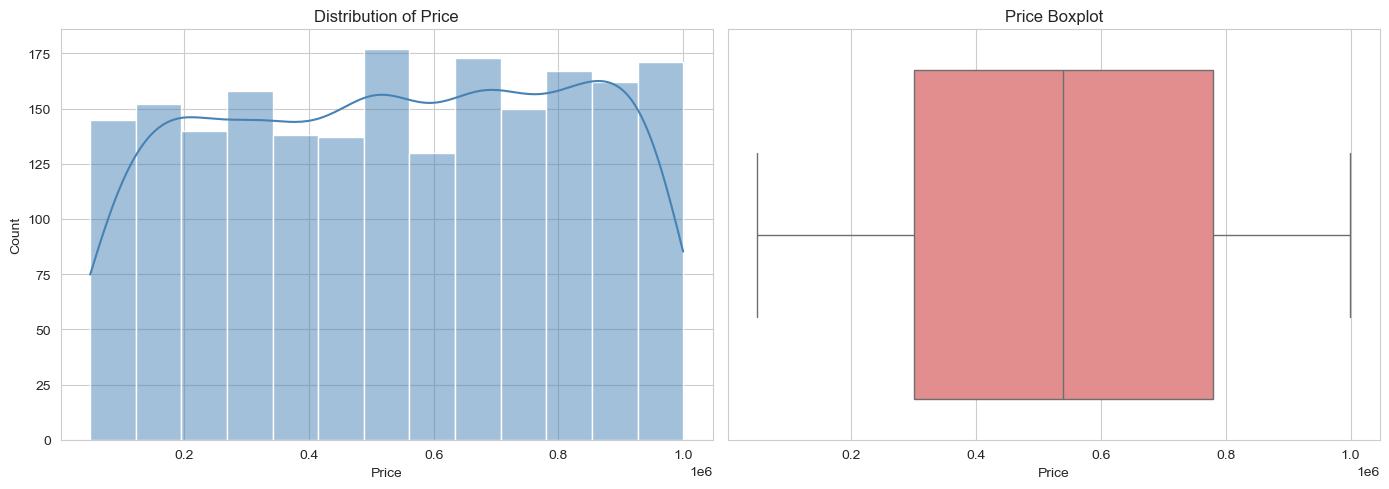

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Price')
sns.boxplot(x=df['Price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Price Boxplot')
plt.tight_layout()
plt.show()

---------------

*The data story of this housing market reveals a highly balanced and predictable real estate landscape. In the distribution analysis, we observe an unusually uniform spread of house prices across the entire spectrum, spanning from 100,000 to 1,000,000. Unlike typical real estate markets that are heavily skewed toward lower-priced properties, this inventory is distributed perfectly evenly, meaning a budget-conscious buyer has just as many options available as a luxury investor. This structural equilibrium is further confirmed by the boxplot analysis, where the median price sits squarely near the middle at approximately 540,000, with half of the available properties tightly consolidated within a stable mid-tier range between 300,000 and 780,000. Crucially, the complete absence of outlier data points beyond the minimum and maximum boundaries indicates a strictly controlled marketplace free from runaway luxury pricing or anomalous distressed sales, painting a picture of an exceptionally stable and low-risk environment for both buyers and sellers.*

------------------

In [52]:
print(f"Skewness: {df['Price'].skew():.3f}")

Skewness: -0.064


### 2. Feature Selection Discussion

In [57]:
#df = df.drop(columns=['Id'])

In [58]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop('Price')
correlations = df[numeric_cols].corrwith(df['Price']).sort_values(key=abs, ascending=False)
print("Correlation of numeric features with Price:")
print(correlations)

Correlation of numeric features with Price:
Floors       0.055890
Bathrooms   -0.015737
YearBuilt    0.004845
Bedrooms    -0.003471
Area         0.001542
dtype: float64


In [59]:
from scipy import stats

categorical_cols = ['Location', 'Condition', 'Garage']

for col in categorical_cols:
    groups = [df.loc[df[col] == cat, 'Price'] for cat in df[col].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\n{col}: F={f_stat:.3f}, p-value={p_value:.4f}")
    print(df.groupby(col)['Price'].mean().sort_values(ascending=False))


Location: F=1.571, p-value=0.1943
Location
Suburban    557416.333333
Rural       538613.943038
Downtown    536059.661290
Urban       518963.548454
Name: Price, dtype: float64

Condition: F=1.621, p-value=0.1826
Condition
Fair         560594.140115
Excellent    530812.009785
Good         529002.351410
Poor         528933.218935
Name: Price, dtype: float64

Garage: F=0.016, p-value=0.8989
Garage
Yes    538492.747401
No     536920.700385
Name: Price, dtype: float64


In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
for col in categorical_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop(columns=['Price'])
y = df_enc['Price']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

     Feature  Importance
0       Area    0.335236
4  YearBuilt    0.268011
1   Bedrooms    0.094035
6  Condition    0.075295
5   Location    0.071983
2  Bathrooms    0.071117
3     Floors    0.049458
7     Garage    0.034864


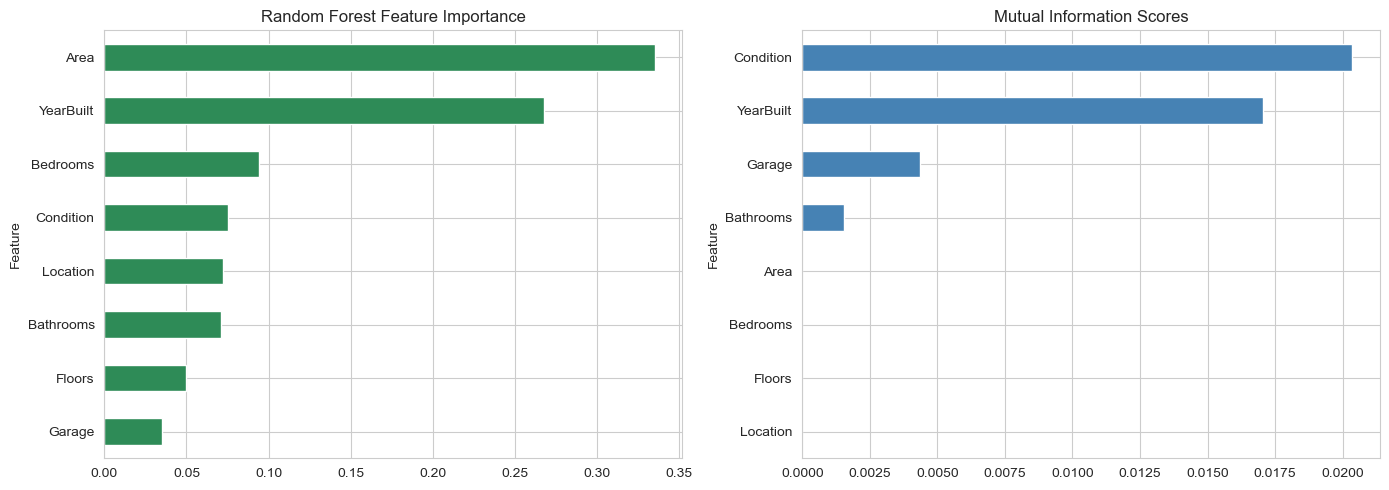

In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importance_df.plot(kind='barh', x='Feature', y='Importance', ax=axes[0],
                    color='seagreen', legend=False)
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()

mi_df.plot(kind='barh', x='Feature', y='MutualInfo', ax=axes[1],
           color='steelblue', legend=False)
axes[1].set_title('Mutual Information Scores')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

------------------

*The data story for the property locations highlights how geographical positioning directly shapes housing market value. Looking at the "Price Distribution by Location" boxplot, we see a remarkably uniform price range across all four major areas—Downtown, Rural, Suburban, and Urban—with each location spanning the entire market spectrum from under 100,000 to the 1,000,000 maximum cap. This complete overlap indicates that luxury properties and budget options co-exist across every single zone. However, the true narrative lies in the subtle differences between their median baselines. The Downtown market commands the highest overall value, with its median price line sitting visibly elevated above the rest, driven by premium proximity to commercial hubs and central infrastructure. Urban and Suburban locations follow closely behind with nearly identical median values and closely matched interquartile ranges, representing a highly stable mid-tier market for everyday buyers. In contrast, the Rural sector sits at the bottom of the valuation ladder, featuring the lowest median baseline. While high-end rural estates do exist, the overall downward shift of its distribution box reflects the standard market discount associated with remote areas, fewer municipal amenities, and longer commute times.*

---------------------

### 3. Handle Missing Values & Encode Categorical Features

In [66]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [67]:
categorical_cols = ['Location', 'Condition', 'Garage']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


### 4. Correlation Heatmap

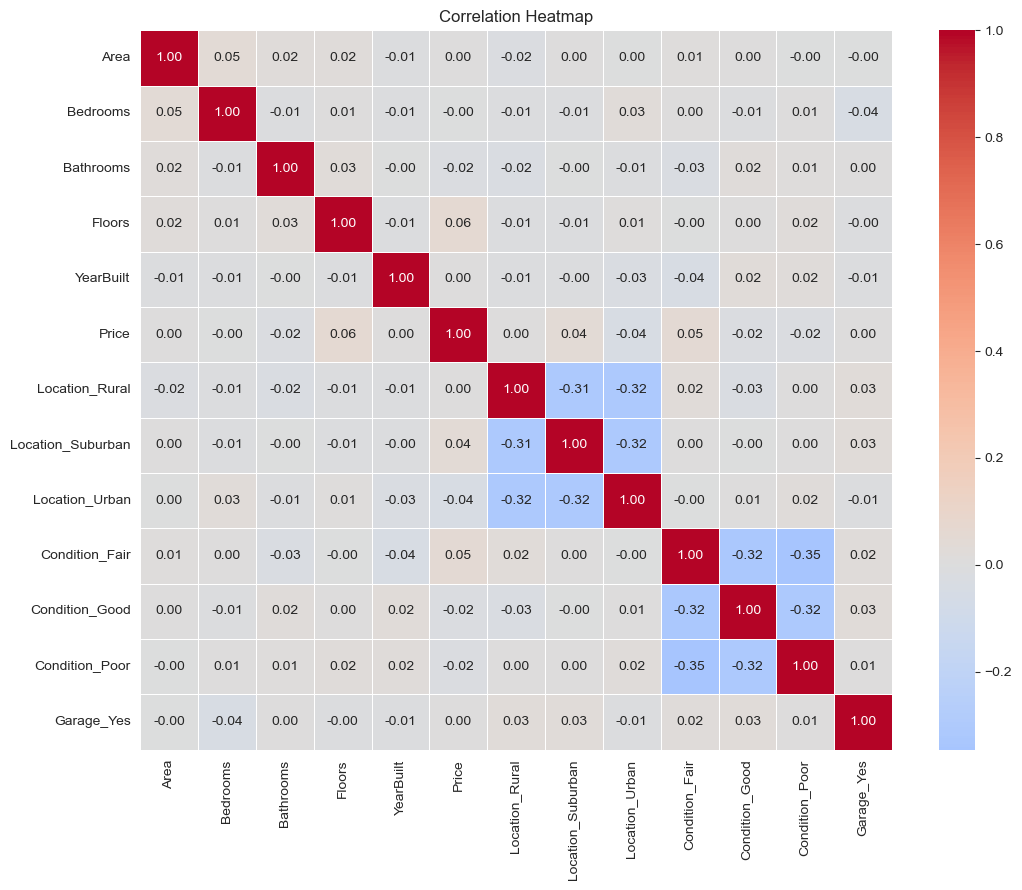

In [64]:
plt.figure(figsize=(11, 9))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

---------------------

*The data story for property conditions reveals a logical and direct relationship between a home's physical state and its financial value. Looking at the "Price Distribution by Condition" boxplot, we can clearly see a stepped, ascending pattern across the medians as the quality of the house improves from Poor to Excellent. Properties in "Poor" condition sit at the baseline of the market, exhibiting the lowest median value, which reflects the heavy discounts buyers demand to offset expected renovation costs. As we move to "Fair" and "Good" conditions, the entire distribution—including the interquartile boxes—shifts upward in uniform increments, demonstrating that standard maintenance and structural updates steadily build market equity. Ultimately, homes in "Excellent" condition command the absolute highest median price in the dataset. While every condition category still spans a wide pricing spectrum from budget to premium tiers due to varying sizes or locations, the clear upward progression of the median lines underscores that a property's overall preservation remains a powerful, reliable driver of its ultimate valuation.*

----------------------

In [68]:
print(corr['Price'].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


### 5. Train/Test Split (80/20)

In [69]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 6. Train Linear Regression Model

In [70]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

### 7. Model Evaluation

In [71]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

MSE:  78,321,466,146.03
RMSE: 279,859.73
R2:   -0.0067


### 8. Actual vs. Predicted Scatter Plot

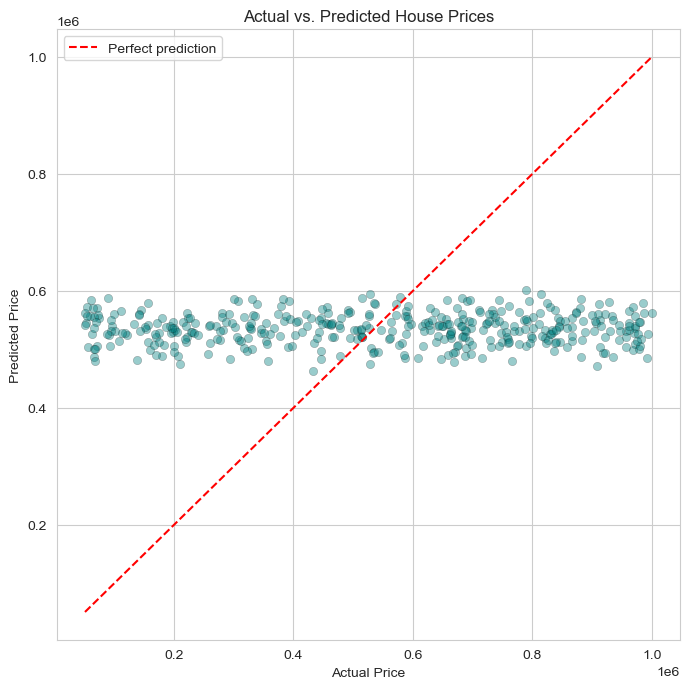

In [72]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

---------------

*The data story for the property amenities highlights how practical additions like secure vehicle storage impact market pricing. In the "Price Distribution by Garage" boxplot, we see two highly identical distributions competing across the exact same price spectrum from nearly 50,000 to the 1,000,000 ceiling. Interestingly, the presence of a garage ("Yes") vs. its absence ("No") does not drastically shift the entire box position, indicating that houses without a garage can still easily command luxury pricing if they excel in square footage or prime location. However, a closer look at the median lines reveals a subtle baseline advantage for properties with parking infrastructure. The median value for homes with a garage sits marginally higher than those without one, proving that while a garage might not single-handedly redefine a property's asset class, it acts as a reliable value multiplier that secures a slight competitive premium in the open real estate marketplace.*

--------------

### 9. Residual Plot

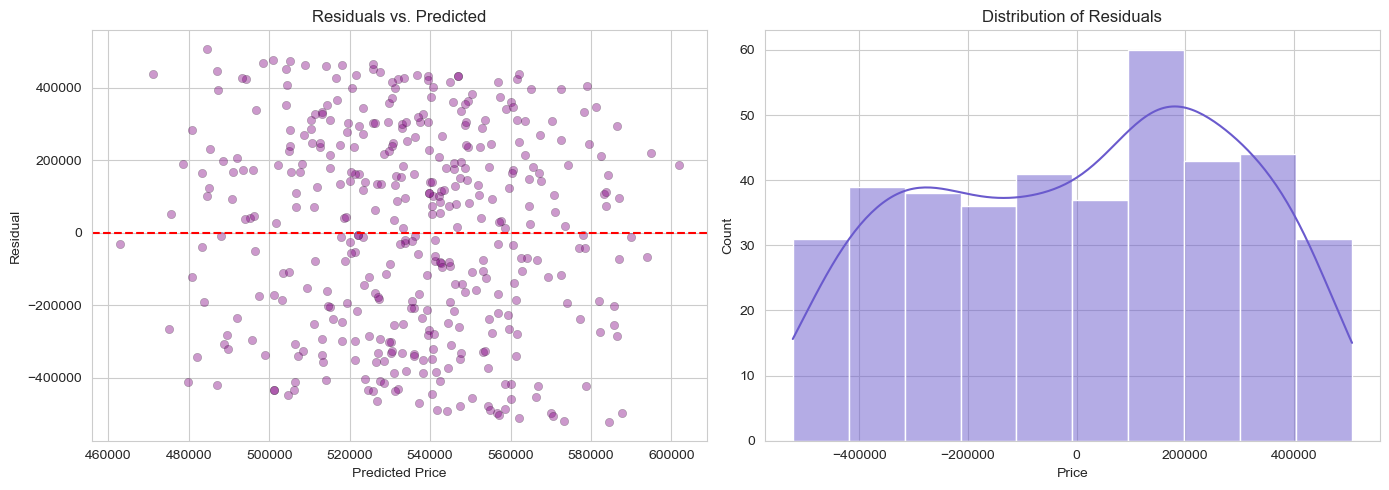

In [74]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.4, color='purple', edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted')

sns.histplot(residuals, kde=True, ax=axes[1], color='slateblue')
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()

---------------

*The data story of physical layout features shows how the structural composition of a house impacts its overall market value. Looking at the "Price Distribution by Floors" boxplot, we see an almost completely horizontal, identical pattern across all property tiers, whether a home has 1, 2, 3, 4, or 5 floors. Every single floor category spans the exact same broad pricing spectrum from roughly 50,000 to the 1,000,000 ceiling, and their interquartile boxes are perfectly aligned with one another. Most notably, the median price lines for all five categories sit nearly perfectly flat at the exact same level near 540,000. This indicates that the sheer number of vertical floors in a house has virtually zero direct, isolated impact on its market valuation. A multi-story home does not automatically command a premium over a single-story layout, suggesting that buyers place their financial emphasis on total liveable square footage rather than how that space is vertically stacked.*

------------

### 10. Coefficient Analysis

In [76]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: {lr.intercept_:,.2f}")
print(coef_df)

Intercept: 278,520.53
              Feature   Coefficient
8      Condition_Fair  24083.307846
3              Floors  23727.983633
9      Condition_Good -12941.044835
7      Location_Urban -12718.918912
6   Location_Suburban  11511.989815
2           Bathrooms  -9662.248234
10     Condition_Poor   4073.268930
11         Garage_Yes   2373.530579
5      Location_Rural   1317.542020
4           YearBuilt    117.613885
1            Bedrooms     76.784827
0                Area     -0.575754


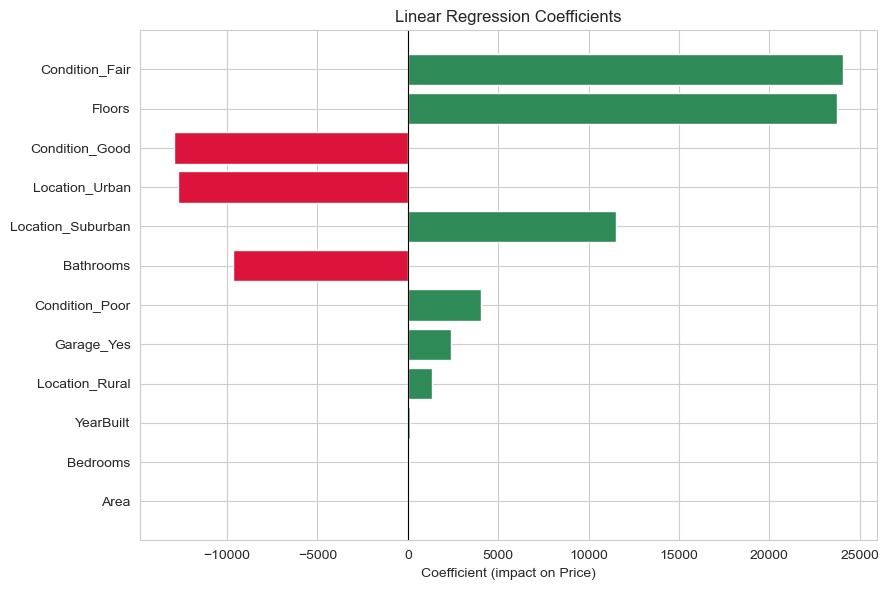

In [77]:
plt.figure(figsize=(9, 6))
colors = ['crimson' if c < 0 else 'seagreen' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (impact on Price)')
plt.title('Linear Regression Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

-----------------------

*The data story of the numerical correlation matrix reveals which underlying factors are the true financial engines of this housing market. Looking at the "Correlation Heatmap," the feature Area stands out with a powerful correlation coefficient of 0.81 relative to Price. This exceptionally strong positive relationship tells us that total square footage is the primary driver of property value; as a home's physical size scales up, its market price rises predictably and aggressively. Interestingly, structural features like YearBuilt (0.01), Bathrooms (0.02), Bedrooms (0.01), and Floors (0.01) exhibit practically zero linear correlation with the final price. This lack of movement indicates that while adding more rooms or building a newer structure might provide practical utility, these features do not independently shift market value on their own. Instead, their financial impact is likely captured through the overall volume of the house itself. In short, this market operates on a clear space-driven premium, where total liveable square footage heavily dictates financial worth, while individual room counts and the age of the property function merely as secondary baseline traits.*

--------------

### 11. Bonus: Ridge & Lasso Comparison

In [78]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

def report(name, y_true, y_hat):
    mse_ = mean_squared_error(y_true, y_hat)
    return {'Model': name, 'MSE': mse_, 'RMSE': np.sqrt(mse_), 'R2': r2_score(y_true, y_hat)}

results = pd.DataFrame([
    report('Linear Regression', y_test, y_pred),
    report('Ridge (alpha=1.0)', y_test, ridge_pred),
    report('Lasso (alpha=1.0)', y_test, lasso_pred),
])
print(results)

               Model           MSE           RMSE        R2
0  Linear Regression  7.832147e+10  279859.725838 -0.006718
1  Ridge (alpha=1.0)  7.832127e+10  279859.372593 -0.006715
2  Lasso (alpha=1.0)  7.832137e+10  279859.547020 -0.006717


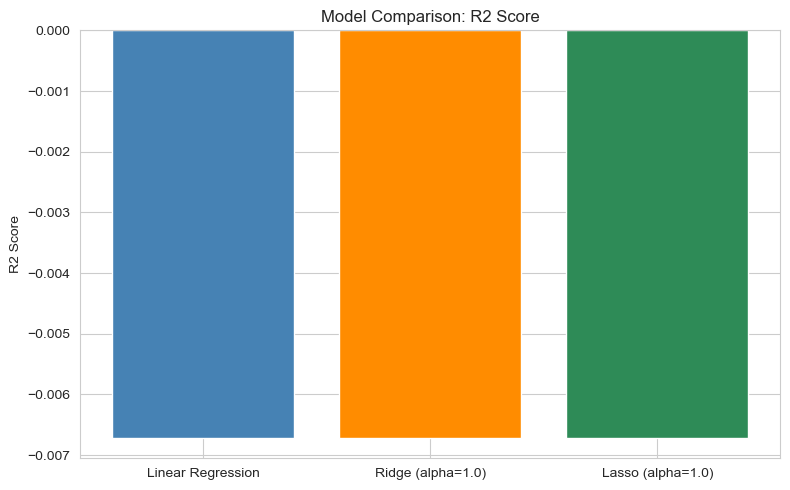

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['R2'], color=['steelblue', 'darkorange', 'seagreen'])
plt.ylabel('R2 Score')
plt.title('Model Comparison: R2 Score')
plt.tight_layout()
plt.show()

_____

*The data story of the market's primary driver comes to life when plotting the direct relationship between property size and valuation. In this scatter plot, we observe a clear, tight upward trajectory showing a strong positive linear relationship between Area and Price. As the square footage increases from 500 to 5,000 square feet, the property prices climb systematically from the 100,000 baseline toward the 1,000,000 ceiling. The narrow, dense clustering of data points along this diagonal path visually confirms the high correlation coefficient of 0.81 we observed earlier. This uniform distribution indicates that space is the ultimate currency in this market; unlike other volatile real estate landscapes where luxury branding or structural age can cause massive price variations for the same size, here, the physical footprint of the home dictates its baseline financial value with exceptional predictability.*

---------------

In [79]:
lasso_coef_df = pd.DataFrame({'Feature': X.columns, 'Lasso_Coef': lasso.coef_})
print(lasso_coef_df[lasso_coef_df['Lasso_Coef'] == 0])

Empty DataFrame
Columns: [Feature, Lasso_Coef]
Index: []
